Analise do dataset a troco de adiantar as metricas, graficos e insights. Quando houver a integração com mongo e etc, ja teremos meio caminho andado


# importacao

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff


from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#  DATASET DE DADOS DE MODO GERAL
(é a base dos dois)

In [143]:
N9.to_csv('N9.csv', index=False)

geral para ter uma filtragem maais assertiva para analisar mentorados.

In [144]:
N9.info()
print(f'{N9.shape}')

N9.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   task_id                        76 non-null     int64  
 1   titulo                         76 non-null     object 
 2   descricao                      76 non-null     object 
 3   prioridade                     76 non-null     object 
 4   mentorado                      76 non-null     object 
 5   area_atuacao                   76 non-null     object 
 6   mentor_responsavel             76 non-null     object 
 7   data_criacao                   76 non-null     object 
 8   data_inicio                    62 non-null     object 
 9   data_conclusao                 43 non-null     object 
 10  status_atual                   76 non-null     object 
 11  feedback_conclusao_ mentorado  0 non-null      float64
dtypes: float64(1), int64(1), object(10)
memory usage: 7.

,task_id,feedback_conclusao_ mentorado
count,76.000000,0.0
mean,38.500000,NaN
std,22.083176,NaN
min,1.000000,NaN
25%,19.750000,NaN
50%,38.500000,NaN
75%,57.250000,NaN
max,76.000000,NaN


In [145]:
#conversao de valores para tipos adequados
N9['task_id'] = N9['task_id'].astype('object')
print(f"Coluna 'task_id' convertida para o tipo '{N9['task_id'].dtype}'")

colunas_data = ['data_criacao', 'data_inicio', 'data_conclusao']
for col in colunas_data:
    N9[col] = pd.to_datetime(N9[col], errors='coerce')
    print(f' colunas dedata foram convertidas com sucesso para o tipo {N9[col].dtype}')
#

Coluna 'task_id' convertida para o tipo 'object'
 colunas dedata foram convertidas com sucesso para o tipo datetime64[ns]
 colunas dedata foram convertidas com sucesso para o tipo datetime64[ns]
 colunas dedata foram convertidas com sucesso para o tipo datetime64[ns]


In [146]:
N9.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   task_id                        76 non-null     object        
 1   titulo                         76 non-null     object        
 2   descricao                      76 non-null     object        
 3   prioridade                     76 non-null     object        
 4   mentorado                      76 non-null     object        
 5   area_atuacao                   76 non-null     object        
 6   mentor_responsavel             76 non-null     object        
 7   data_criacao                   76 non-null     datetime64[ns]
 8   data_inicio                    62 non-null     datetime64[ns]
 9   data_conclusao                 43 non-null     datetime64[ns]
 10  status_atual                   76 non-null     object        
 11  feedback_conclusao_ m

In [147]:
N9.head()

,task_id,titulo,descricao,prioridade,mentorado,area_atuacao,mentor_responsavel,data_criacao,data_inicio,data_conclusao,status_atual,feedback_conclusao_ mentorado
0,1,Otimizar Microsserviços - Sprint 8,Atividade focada em otimizar o recurso de micr...,media,Bruno Costa,DevBack-end,Juliana Costa,2026-05-05,2026-05-07,NaT,andamento,NaN
1,2,Testar Scripts de Deploy - Sprint 2,Atividade focada em testar o recurso de script...,alta,Felipe Andrade,QA,Juliana Costa,2026-03-25,2026-03-27,2026-04-02,concluida,NaN
2,3,Testar Cache em Redis - Sprint 2,Atividade focada em testar o recurso de cache ...,media,Felipe Andrade,QA,Juliana Costa,2026-03-26,2026-03-27,2026-04-06,concluida,NaN
3,4,Testar Componentes React - Sprint 8,Atividade focada em testar o recurso de compon...,media,Diego Martins,QA,Juliana Costa,2026-04-20,2026-04-21,2026-04-27,concluida,NaN
4,5,Ajustar Exportação de Relatórios - Sprint 3,Atividade focada em ajustar o recurso de expor...,media,Camila Lopes,Produto,Juliana Costa,2026-03-02,2026-03-05,2026-03-19,concluida,NaN


In [148]:
N9.drop(columns=['descricao', 'mentor_responsavel', 'feedback_conclusao_ mentorado'], inplace=True, errors='ignore')

In [149]:
##como temos valores nulos de data de inicio e data de  conclusao q estao nulos, estamos falando de atividades que não foram concluidas/iniadas
N9.isnull().sum()

,0
task_id,0
titulo,0
prioridade,0
mentorado,0
area_atuacao,0
data_criacao,0
data_inicio,14
data_conclusao,33
status_atual,0


In [150]:
N9.duplicated().sum()

np.int64(0)

In [151]:
N9.head()

,task_id,titulo,prioridade,mentorado,area_atuacao,data_criacao,data_inicio,data_conclusao,status_atual
0,1,Otimizar Microsserviços - Sprint 8,media,Bruno Costa,DevBack-end,2026-05-05,2026-05-07,NaT,andamento
1,2,Testar Scripts de Deploy - Sprint 2,alta,Felipe Andrade,QA,2026-03-25,2026-03-27,2026-04-02,concluida
2,3,Testar Cache em Redis - Sprint 2,media,Felipe Andrade,QA,2026-03-26,2026-03-27,2026-04-06,concluida
3,4,Testar Componentes React - Sprint 8,media,Diego Martins,QA,2026-04-20,2026-04-21,2026-04-27,concluida
4,5,Ajustar Exportação de Relatórios - Sprint 3,media,Camila Lopes,Produto,2026-03-02,2026-03-05,2026-03-19,concluida


# analisegeral


In [152]:
databcorte = pd.to_datetime('2026-05-31') #é a fotografia da data, é oq nos ajuda a criar o limite pra uma data que não existe, exemplo data_inicio ou data_conclusao. Ela pode ser modificada, podemos dar outro parametro de data.

N9['duracao_em_dias'] = np.nan #criar uma coluna vazia para receber os calculos

taskconcluida = N9['status_atual'] == 'concluida'
N9.loc[taskconcluida, 'duracao_em_dias'] = (N9.loc[taskconcluida, 'data_conclusao'] - N9.loc[taskconcluida, 'data_inicio']).dt.days  # CONCLUIDAS = DATAINICIO - DATACONCLUSAO.

# 'andamento' status
task_andamento = N9['status_atual'] == 'andamento'

N9.loc[task_andamento, 'duracao_em_dias'] = (databcorte - N9.loc[task_andamento, 'data_inicio']).dt.days #DATA CORTE AGR É UMA DATA Q O SISTEMA TA DANDO COMO LIMITE PARA AS ATVD Q ESTAO EM ANDAMENTO. como se ele dissesse: Olhe, datacorte-datainicio = a qntdade de dias q ja se passaram e vc ainda ta em andamento com a atvd

# 'pendente' status
task_pendente = N9['status_atual'] == 'pendente'
N9.loc[task_pendente, 'duracao_em_dias'] = (databcorte - N9.loc[task_pendente, 'data_criacao']).dt.days # ele vai pegar a datacorte - datacriacao e sinalizar: olhe, ate agora(data_corte), vc ta com essa atividade ha X dias no blocklog


#duraçao em dias para saber quantos dias aquela tarefa foi concluida ou esta em processo/pendente
concluidas = N9[N9['status_atual'] == 'concluida']
andamento = N9[N9['status_atual'] == 'andamento']
pendentes = N9[N9['status_atual'] == 'pendente']

# Calcular as médias isoladas (arredondadas a 1 casa decimal). O papel da média vai nos dizer: se a quantidade de dias que a atvd ta em execução/pendente é maior que a média, ai isso ja dá um alerta pra o mentor conversar procurar o mentorado e entender oq se passa
media_dia_conclusao = concluidas['duracao_em_dias'].mean().round(1)
media_dia_andamento = andamento['duracao_em_dias'].mean().round(1)
media_dia_pendente = pendentes['duracao_em_dias'].mean().round(1)


print(f'a media de dias para concluir é: {media_dia_conclusao}')
print(f'a media de dias que a atv ESTÁ EM ANDAMENTO é: {media_dia_andamento}' )
print(f'a media de dias de atv pendente é: {media_dia_pendente}')
print(concluidas)
print('===========')
print(andamento)
print('===========')
print(pendentes)

a media de dias para concluir é: 10.7
a media de dias que a atv ESTÁ EM ANDAMENTO é: 16.2
a media de dias de atv pendente é: 11.8
   task_id                                          titulo prioridade  \
1        2             Testar Scripts de Deploy - Sprint 2       alta   
2        3                Testar Cache em Redis - Sprint 2      media   
3        4             Testar Componentes React - Sprint 8      media   
4        5     Ajustar Exportação de Relatórios - Sprint 3      media   
7        8              Criar Scripts de Deploy - Sprint 2       alta   
9       10                      Criar Dashboard - Sprint 1      media   
10      11             Atualizar Pipeline CI/CD - Sprint 1      media   
11      12             Refatorar Microsserviços - Sprint 5      media   
12      13               Refatorar API de Login - Sprint 5       alta   
13      14             Documentar Tabelas no BD - Sprint 4      baixa   
14      15                 Criar Pipeline CI/CD - Sprint 6       al

In [153]:
N9['status_atual'].value_counts()
print(f'{N9["status_atual"].value_counts()}')

#agr sabemos como estao as atividades e os status gerais

status_atual
concluida    43
andamento    19
pendente     14
Name: count, dtype: int64


In [154]:
#
N9['status_atual'].value_counts(normalize=True) * 100

,proportion
status_atual,
concluida,56.578947
andamento,25.000000
pendente,18.421053


In [155]:
#distribuição de status_atual por mentorado
N9.groupby('mentorado')['status_atual'].value_counts(normalize=True) * 100

#podemos tirar daqui q o caount nos mostra quantas vezes os mentorados tem atividade

mentorado       status_atual
Ana Ribeiro     concluida       62.500000
                andamento       18.750000
                pendente        18.750000
Bruno Costa     concluida       70.000000
                pendente        20.000000
                andamento       10.000000
Camila Lopes    concluida       42.857143
                pendente        42.857143
                andamento       14.285714
Diego Martins   pendente        44.444444
                concluida       33.333333
                andamento       22.222222
Eduarda Souza   concluida       70.000000
                andamento       30.000000
Felipe Andrade  concluida       70.000000
                andamento       20.000000
                pendente        10.000000
Gabriela Pinto  concluida       50.000000
                andamento       40.000000
                pendente        10.000000
Henrique Alves  andamento       75.000000
                concluida       25.000000
Name: proportion, dtype: float64

In [156]:
N9.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   task_id          76 non-null     object        
 1   titulo           76 non-null     object        
 2   prioridade       76 non-null     object        
 3   mentorado        76 non-null     object        
 4   area_atuacao     76 non-null     object        
 5   data_criacao     76 non-null     datetime64[ns]
 6   data_inicio      62 non-null     datetime64[ns]
 7   data_conclusao   43 non-null     datetime64[ns]
 8   status_atual     76 non-null     object        
 9   duracao_em_dias  76 non-null     float64       
dtypes: datetime64[ns](3), float64(1), object(6)
memory usage: 6.1+ KB


In [157]:
media_por_prioridade = N9.groupby('prioridade')['duracao_em_dias'].mean().round(1)
print(media_por_prioridade)

prioridade
alta     11.5
baixa    11.6
media    13.5
Name: duracao_em_dias, dtype: float64


#EDA -  MENTORADA


In [158]:
mentorada = N9[N9['mentorado'] == 'Ana Ribeiro'].copy()
mentorada.head(16)

,task_id,titulo,prioridade,mentorado,area_atuacao,data_criacao,data_inicio,data_conclusao,status_atual,duracao_em_dias
7,8,Criar Scripts de Deploy - Sprint 2,alta,Ana Ribeiro,Data Engineer,2026-04-20,2026-04-21,2026-04-30,concluida,9.0
10,11,Atualizar Pipeline CI/CD - Sprint 1,media,Ana Ribeiro,Data Engineer,2026-03-04,2026-03-05,2026-03-12,concluida,7.0
13,14,Documentar Tabelas no BD - Sprint 4,baixa,Ana Ribeiro,Data Engineer,2026-04-15,2026-04-16,2026-05-01,concluida,15.0
14,15,Criar Pipeline CI/CD - Sprint 6,alta,Ana Ribeiro,Data Engineer,2026-04-21,2026-04-23,2026-05-10,concluida,17.0
17,18,Implementar Scripts de Deploy - Sprint 1,alta,Ana Ribeiro,Data Engineer,2026-05-12,2026-05-17,NaT,andamento,14.0
21,22,Documentar Tabelas no BD - Sprint 6,baixa,Ana Ribeiro,Data Engineer,2026-03-20,2026-03-22,2026-04-01,concluida,10.0
30,31,Atualizar Scripts de Deploy - Sprint 6,alta,Ana Ribeiro,Data Engineer,2026-05-08,2026-05-11,2026-05-31,concluida,20.0
31,32,Ajustar Pipeline CI/CD - Sprint 9,alta,Ana Ribeiro,Data Engineer,2026-03-05,2026-03-08,2026-03-13,concluida,5.0
34,35,Implementar Tabelas no BD - Sprint 5,alta,Ana Ribeiro,Data Engineer,2026-05-14,NaT,NaT,pendente,17.0
36,37,Otimizar Pipeline CI/CD - Sprint 2,media,Ana Ribeiro,Data Engineer,2026-05-10,NaT,NaT,pendente,21.0


In [159]:
media_prioridade_Ana = mentorada.groupby('prioridade')['duracao_em_dias'].mean().round(1)
print(media_prioridade_Ana)

prioridade
alta     11.2
baixa    12.5
media    15.7
Name: duracao_em_dias, dtype: float64


In [160]:
media_por_status_ana = mentorada.groupby('status_atual')['duracao_em_dias'].mean().round(1)
print(media_por_status_ana)

status_atual
andamento     7.0
concluida    13.2
pendente     14.0
Name: duracao_em_dias, dtype: float64


In [161]:
mentorada.describe()

,data_criacao,data_inicio,data_conclusao,duracao_em_dias
count,16,13,10,16.000000
mean,2026-04-19 09:00:00,2026-04-15 07:23:04.615384576,2026-04-16 21:36:00,12.187500
min,2026-03-03 00:00:00,2026-03-04 00:00:00,2026-03-12 00:00:00,2.000000
25%,2026-03-21 12:00:00,2026-03-22 00:00:00,2026-03-25 06:00:00,6.500000
50%,2026-04-22 12:00:00,2026-04-21 00:00:00,2026-04-17 12:00:00,12.500000
75%,2026-05-12 12:00:00,2026-05-11 00:00:00,2026-05-07 18:00:00,17.500000
max,2026-05-27 00:00:00,2026-05-29 00:00:00,2026-05-31 00:00:00,21.000000
std,NaN,NaN,NaN,6.358393


In [162]:
duracao_em_dias_series = mentorada['duracao_em_dias']

duracao_em_dias_series.quantile([0.25, 0.5, 0.75])
IQR = duracao_em_dias_series.quantile(0.75) - duracao_em_dias_series.quantile(0.25)
print(IQR)
Q1 = duracao_em_dias_series.quantile(0.25)
Q3 = duracao_em_dias_series.quantile(0.75)
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
print(f'Limite Inferior: {limite_inferior}')
print(f'Limite Superior: {limite_superior}')

11.0
Limite Inferior: -10.0
Limite Superior: 34.0


In [163]:
historico = N9[N9['status_atual'] == 'concluida']# vai se basear nas entregas do geral de mentorados
media_geral_por_prioridade = historico.groupby('prioridade')['duracao_em_dias'].mean().round(0) #usamos os dados do dataset geral
print(media_geral_por_prioridade)


tarefas_ativas = mentorada[mentorada['status_atual'].isin(['andamento', 'pendente'])].copy()
tarefas_ativas['tempo_limite'] = tarefas_ativas['prioridade'].map(media_geral_por_prioridade) # O .map() olha a prioridade da tarefa e "cola" o tempo limite exato na coluna ao lado.
print(tarefas_ativas)

prioridade
alta     10.0
baixa    10.0
media    11.0
Name: duracao_em_dias, dtype: float64
   task_id                                    titulo prioridade    mentorado  \
17      18  Implementar Scripts de Deploy - Sprint 1       alta  Ana Ribeiro   
34      35      Implementar Tabelas no BD - Sprint 5       alta  Ana Ribeiro   
36      37        Otimizar Pipeline CI/CD - Sprint 2      media  Ana Ribeiro   
49      50           Criar Pipeline CI/CD - Sprint 7       alta  Ana Ribeiro   
56      57     Otimizar Scripts de Deploy - Sprint 8       alta  Ana Ribeiro   
66      67    Atualizar Scripts de Deploy - Sprint 9       alta  Ana Ribeiro   

     area_atuacao data_criacao data_inicio data_conclusao status_atual  \
17  Data Engineer   2026-05-12  2026-05-17            NaT    andamento   
34  Data Engineer   2026-05-14         NaT            NaT     pendente   
36  Data Engineer   2026-05-10         NaT            NaT     pendente   
49  Data Engineer   2026-05-25  2026-05-29          

In [164]:
historico = N9[N9['status_atual'] == 'concluida']# vai se basear nas entregas do geral de mentorados
media_geral_por_prioridade = historico.groupby('prioridade')['duracao_em_dias'].mean().round(0) #usamos os dados do dataset geral
print(media_geral_por_prioridade)


tarefas_ativas = N9[N9['status_atual'].isin(['andamento', 'pendente'])].copy()
tarefas_ativas['tempo_limite'] = tarefas_ativas['prioridade'].map(media_geral_por_prioridade) # O .map() olha a prioridade da tarefa e "cola" o tempo limite exato na coluna ao lado.
print(tarefas_ativas)

prioridade
alta     10.0
baixa    10.0
media    11.0
Name: duracao_em_dias, dtype: float64
   task_id                                            titulo prioridade  \
0        1                Otimizar Microsserviços - Sprint 8      media   
5        6       Documentar Acessibilidade (WCAG) - Sprint 7      baixa   
6        7                    Criar API de Login - Sprint 10       alta   
8        9        Atualizar Acessibilidade (WCAG) - Sprint 1      media   
15      16    Documentar Exportação de Relatórios - Sprint 9      baixa   
17      18          Implementar Scripts de Deploy - Sprint 1       alta   
18      19               Criar Componentes React - Sprint 10       alta   
23      24               Testar Scripts de Deploy - Sprint 2       alta   
24      25         Otimizar Fluxo de Autenticação - Sprint 8       alta   
25      26            Atualizar Componentes React - Sprint 5      media   
26      27                     Criar API de Login - Sprint 2       alta   
27      2

In [165]:
mentorada.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16 entries, 7 to 71
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   task_id          16 non-null     object        
 1   titulo           16 non-null     object        
 2   prioridade       16 non-null     object        
 3   mentorado        16 non-null     object        
 4   area_atuacao     16 non-null     object        
 5   data_criacao     16 non-null     datetime64[ns]
 6   data_inicio      13 non-null     datetime64[ns]
 7   data_conclusao   10 non-null     datetime64[ns]
 8   status_atual     16 non-null     object        
 9   duracao_em_dias  16 non-null     float64       
dtypes: datetime64[ns](3), float64(1), object(6)
memory usage: 1.9+ KB


In [166]:
mentorada.isnull().sum()

,0
task_id,0
titulo,0
prioridade,0
mentorado,0
area_atuacao,0
data_criacao,0
data_inicio,3
data_conclusao,6
status_atual,0
duracao_em_dias,0


In [167]:
mentorada.duplicated().sum()

np.int64(0)

#GRAFICOS

##card - valores totais, médias gerais, ou algo muito expecidfico

In [168]:
datacorte = pd.to_datetime('2026-05-31') #valor para parametro de atvs n iniciadas ou em andamento, ja sabemos as atvds q foram finalizadas

O total de atividade de Ana é: 16


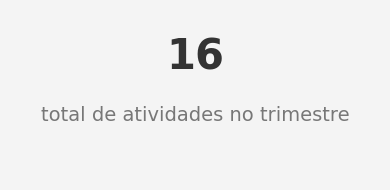

In [169]:
#CARD total de atividade escaladas(sugestao)
mentorada['status_atual'].count()
print(f'O total de atividade de Ana é: {mentorada["status_atual"].count()}')


fig, ax = plt.subplots(figsize=(4, 2))
ax.patch.set_facecolor('#f4f4f4')
fig.patch.set_facecolor('#f4f4f4')

# Remover bordas
for spine in ax.spines.values():
    spine.set_visible(False)

# Remover eixos
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

# Textos do card (métrica e label)
ax.text(0.5, 0.65, '16', fontsize=30, fontweight='bold', ha='center', color='#333333')
ax.text(0.5, 0.35, 'total de atividades no trimestre', fontsize=14, ha='center', color='#777777')

plt.tight_layout()
plt.show()

Total de atividade concluidas de Ana é: 10


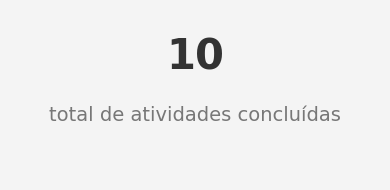

In [170]:
#card total de atividades concluidas no trimestre
total_concluidas = mentorada[mentorada['status_atual'] == 'concluida'].shape[0]
print(f'Total de atividade concluidas de Ana é: {total_concluidas}')

fig, ax = plt.subplots(figsize=(4, 2))
ax.patch.set_facecolor('#f4f4f4')
fig.patch.set_facecolor('#f4f4f4')

# Remover bordas
for spine in ax.spines.values():
    spine.set_visible(False)

# Remover eixos
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)

# Textos do card (métrica e label)
ax.text(0.5, 0.65, str(total_concluidas), fontsize=30, fontweight='bold', ha='center', color='#333333')
ax.text(0.5, 0.35, 'total de atividades concluídas', fontsize=14, ha='center', color='#777777')

plt.tight_layout()
plt.show()

tempo médio(em dias) da conclusão é:13.2
tempo médio(em dias) do andamento é:7.0
tempo médio(em dias) da pendencia é:14.0


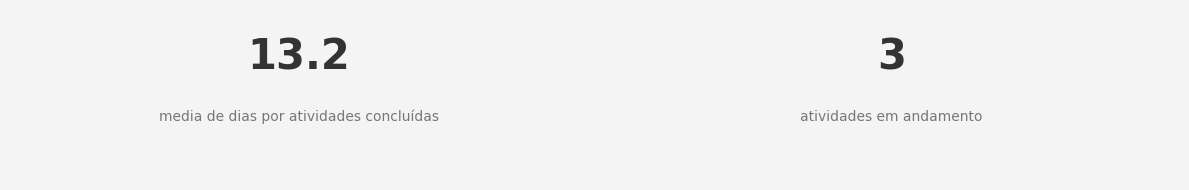

In [171]:
#CARD TEMPO MEDIO POR ENTREGA
mediaconclusao = mentorada[mentorada['status_atual'] == 'concluida']['duracao_em_dias'].mean().round(1)
print(f'tempo médio(em dias) da conclusão é:{mediaconclusao}')
#card tempo medio por atividade em processo
mediandamento = mentorada[mentorada['status_atual'] == 'andamento']['duracao_em_dias'].mean().round(1)
print(f'tempo médio(em dias) do andamento é:{mediandamento}')
#card tempo medio que uma atividade fica pendente
mediapendente = mentorada[mentorada['status_atual'] == 'pendente']['duracao_em_dias'].mean().round(1)
print(f'tempo médio(em dias) da pendencia é:{mediapendente}')

TotalAtvAndamento = len(mentorada[mentorada['status_atual'] == 'andamento'])
fig, axes = plt.subplots(1, 2, figsize=(12, 2)) # 1 row, 2 columns

# Card 1: Concluídas
ax = axes[0]
ax.patch.set_facecolor('#f4f4f4')
fig.patch.set_facecolor('#f4f4f4')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.text(0.5, 0.65, str(mediaconclusao), fontsize=30, fontweight='bold', ha='center', color='#333333', transform=ax.transAxes)
ax.text(0.5, 0.35, 'media de dias por atividades concluídas', fontsize=10, ha='center', color='#777777', transform=ax.transAxes)

# Card 2: Em Andamento
ax = axes[1]
ax.patch.set_facecolor('#f4f4f4')
fig.patch.set_facecolor('#f4f4f4')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.text(0.5, 0.65, str(TotalAtvAndamento), fontsize=30, fontweight='bold', ha='center', color='#333333', transform=ax.transAxes)
ax.text(0.5, 0.35, 'atividades em andamento', fontsize=10, ha='center', color='#777777', transform=ax.transAxes)


plt.tight_layout()
plt.show()

## PIZZA GRAFICO



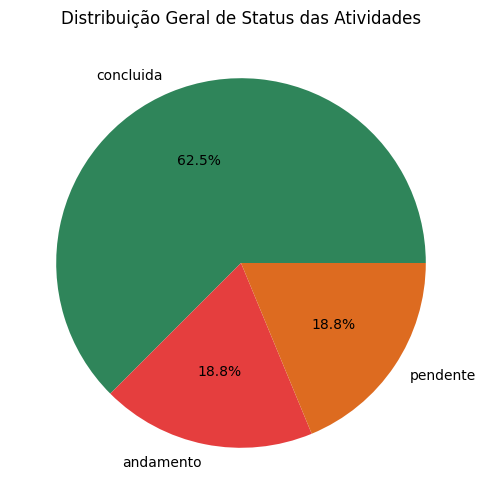

status_atual
concluida    10
andamento     3
pendente      3
Name: count, dtype: int64


In [172]:
#porcentagem de atividadesZ
status_andamento = mentorada['status_atual'].value_counts(normalize=True) * 100
#mentorada['status_atual'].value_counts(normalize=True) * 100 (para calcular ser ver o grafico)

# --- GRÁFICO 1: PIZZA (%STATUS DE TAREFAS DA MENTORA) ---

status_andamento = mentorada['status_atual'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(status_andamento, labels=status_andamento.index, autopct='%1.1f%%', colors=['#2f855a', '#e53e3e', '#dd6b20'])
plt.title('Distribuição Geral de Status das Atividades')
plt.savefig('grafico_status.png', transparent=True)

plt.show()
print(status_andamento)

GRAFICO DINAMICO

In [173]:
# o grafico grande que é aO GRAFICO DE ANA Q MOSTRA AS ENTREGAS AO LONGO DAS SPRINGS.

#base ado nos dados gerais de todos os mentorados
concluidas_equipe = N9[N9['status_atual'] == 'concluida']
media_equipe = concluidas_equipe['duracao_em_dias'].mean()
teto_do_grafico = concluidas_equipe['duracao_em_dias'].max() + 2

# 2. pra cada atividade
mapa_de_cores = {
    'alta': '#E74C3C',    # Vermelho Alerta
    'Alta': '#E74C3C',
    'média': '#F39C12',   # Laranja/Amarelo Atenção
    'media': '#F39C12',
    'Média': '#F39C12',
    'baixa': '#2ECC71',   # Verde Tranquilo
    'Baixa': '#2ECC71'
}

# 3. definir grafico
def criar_grafico_evolucao(dataset_alvo, titulo_do_grafico):

    df_plot = dataset_alvo[dataset_alvo['status_atual'] == 'concluida'].copy()

#separar por sring
    df_plot['sprint_num'] = df_plot['titulo'].str.extract(r'Sprint (\d+)').astype(int)
    df_plot['nome_sprint'] = df_plot['titulo'].str.extract(r'(Sprint \d+)')
    df_plot = df_plot.sort_values('sprint_num')

    fig = px.scatter(
        df_plot,
        x='nome_sprint',
        y='duracao_em_dias',
        color='prioridade',
        color_discrete_map=mapa_de_cores,
        hover_data=['titulo', 'mentorado'],
        title=titulo_do_grafico,
        labels={'duracao_em_dias': 'Dias Gastos', 'nome_sprint': 'Sprint', 'prioridade': 'Dificuldade'}
    )

    fig.add_hline(
        y=media_equipe,
        line_dash="dash",
        line_color="gray",
        annotation_text=f"Média Geral ({media_equipe:.1f} dias)",
        annotation_position="bottom right"
    )

    # bolas do grafico
    fig.update_traces(marker=dict(size=14, opacity=0.8, line=dict(width=1, color='DarkSlateGrey')))
    fig.update_yaxes(range=[0, teto_do_grafico])

    return fig

# 3. GERANDO OS DOIS GRÁFICOS COM 1 LINHA DE CÓDIGO CADA

grafico_ana = criar_grafico_evolucao(mentorada, "Visão da Ana: Minha Evolução Individual")

# Exibindo as duas obras de arte

grafico_ana.show()

#oq esta acontecendo? : ele pega os dias gastos(duraçao_em_dias das atividades CONCLUIDAS) e coloca as sprint, ai podemos ver, de forma dinamica, as tarefas q foram concluidas, e as informações contidas

##Tabela

In [178]:

#usar o historico de entregas de todos os mentorados para ter um parametro de atividade dos mentorados atravez das
historico_geral = N9[N9['status_atual'] == 'concluida']
media_por_prioridade = historico_geral.groupby('prioridade')['duracao_em_dias'].mean().round(1)

tabela_ativas_ana = mentorada[mentorada['status_atual'].isin(['andamento', 'pendente'])].copy()

# Injetamos a meta na tabela da Ana cruzando a prioridade
mentorada['meta_dias_ana'] = mentorada['prioridade'].map(media_por_prioridade)

def sinalizar_status_real(linha): #verificação linha por linha do pandas para chegar nos resultados
    dias = linha['duracao_em_dias'] #mostra há quantos dias aquela atividade está rolando (desde que foi criada ou iniciada até a nossa data de corte).
    meta = linha['meta_dias_ana'] # é a media_por_prioridade que esta convertida em tabela

    if linha['status_atual'] == 'pendente':
        return '🔴 Crítico (Fila)' if dias > 10 else '⚪ Pendente Normal'

    elif linha['status_atual'] == 'andamento':
        if dias > (meta * 2):
            return '🔴 Crítico'
        elif dias > meta:
            return '🟡 Atrasado'
        else:
            # Adicionado para tarefas em 'andamento' mas 'Dentro do Prazo'
            return '🟢 Dentro do Prazo'
    else:
        # Adicionado para tarefas 'concluida' que não tinham retorno
        return '✔️ Entregue'

mentorada['Diagnostico'] = mentorada.apply(sinalizar_status_real, axis=1)
mentorada['dias_de_atraso'] = mentorada['duracao_em_dias'] - mentorada['meta_dias_ana']

atvd_ativa_ = mentorada[mentorada['status_atual'].isin(['andamento', 'pendente'])].copy()

tabela_completa_ana = atvd_ativa_[[
    'titulo', 'mentorado', 'prioridade', 'status_atual',
    'duracao_em_dias', 'meta_dias', 'dias_de_atraso', 'Diagnostico'
]].sort_values(by='dias_de_atraso', ascending=False)




condicao_problema_ana = tabela_completa_ana['Diagnostico'].str.contains('🔴|🟡')
tabela_problemas_ana = tabela_completa_ana[condicao_problema_ana].drop(columns=['dias_de_atraso'])


print("=== TABELA DE visualização de atividades não entregues) ===")
display(tabela_problemas_ana)


=== TABELA DE visualização de atividades não entregues) ===


,titulo,mentorado,prioridade,status_atual,duracao_em_dias,meta_dias,Diagnostico
36,Otimizar Pipeline CI/CD - Sprint 2,Ana Ribeiro,media,pendente,21.0,11.4,🔴 Crítico (Fila)
34,Implementar Tabelas no BD - Sprint 5,Ana Ribeiro,alta,pendente,17.0,10.3,🔴 Crítico (Fila)
17,Implementar Scripts de Deploy - Sprint 1,Ana Ribeiro,alta,andamento,14.0,10.3,🟡 Atrasado


In [182]:
# 2. TABELA DE FLUXO NORMAL (Apenas 🟢 Prazo e ⚪ Fila Normal)
condicao_saudavel_ana = tabela_completa_ana['Diagnostico'].str.contains('🟢|⚪')
tabela_saudaveis_ana = tabela_completa_ana[condicao_saudavel_ana].drop(columns=['dias_de_atraso'])


display(tabela_saudaveis_ana)


,titulo,mentorado,prioridade,status_atual,duracao_em_dias,meta_dias,Diagnostico
66,Atualizar Scripts de Deploy - Sprint 9,Ana Ribeiro,alta,andamento,5.0,10.3,🟢 Dentro do Prazo
56,Otimizar Scripts de Deploy - Sprint 8,Ana Ribeiro,alta,pendente,4.0,10.3,⚪ Pendente Normal
49,Criar Pipeline CI/CD - Sprint 7,Ana Ribeiro,alta,andamento,2.0,10.3,🟢 Dentro do Prazo


TABELA PARA VISUALIZAR OS SALDOS DE TODOS OS MENTORADOS E SUAS ATIVIDADES Q ESTAO FORA DA

In [183]:

#tabela geral
historico_geral = N9[N9['status_atual'] == 'concluida']
media_por_prioridade = historico_geral.groupby('prioridade')['duracao_em_dias'].mean().round(1)

tabela_ativas_ana = N9[N9['status_atual'].isin(['andamento', 'pendente'])].copy()

# Injetamos a meta na tabela N9 cruzando a prioridade
N9['meta_dias'] = N9['prioridade'].map(media_por_prioridade)

def sinalizar_status_real(linha):
    dias = linha['duracao_em_dias']
    meta = linha['meta_dias']

    if linha['status_atual'] == 'pendente':
        return '🔴 Crítico (Fila)' if dias > 10 else '⚪ Pendente Normal'

    elif linha['status_atual'] == 'andamento':
        if dias > (meta * 2):
            return '🔴 Crítico'
        elif dias > meta:
            return '🟡 Atrasado'
        else:
            # Adicionado para tarefas em 'andamento' mas 'Dentro do Prazo'
            return '🟢 Dentro do Prazo'
    else:
        # Adicionado para tarefas 'concluida' que não tinham retorno
        return '✔️ Entregue'

N9['Diagnostico'] = N9.apply(sinalizar_status_real, axis=1)
N9['dias_de_atraso'] = N9['duracao_em_dias'] - N9['meta_dias']

# Pegamos apenas quem NÃO está concluído
tabela_ativas = N9[N9['status_atual'].isin(['andamento', 'pendente'])].copy()


tabela_completa = tabela_ativas[[
    'titulo', 'mentorado', 'prioridade', 'status_atual',
    'duracao_em_dias', 'meta_dias', 'dias_de_atraso', 'Diagnostico'
]].sort_values(by='dias_de_atraso', ascending=False)


#fazer o filtro para não mostrar nada que esteja ok, entregue ou no prazo
condicao_problema = tabela_completa['Diagnostico'].str.contains('🔴|🟡')
tabela_problemas = tabela_completa[condicao_problema].drop(columns=['dias_de_atraso'])


print("=== TABELA DE verificação de tividades não entregues")
display(tabela_problemas)


=== TABELA DE verificação de tividades não entregues


,titulo,mentorado,prioridade,status_atual,duracao_em_dias,meta_dias,Diagnostico
5,Documentar Acessibilidade (WCAG) - Sprint 7,Henrique Alves,baixa,andamento,24.0,10.2,🔴 Crítico
46,Testar Fluxo de Autenticação - Sprint 3,Felipe Andrade,alta,andamento,24.0,10.3,🔴 Crítico
45,Testar Scripts de Deploy - Sprint 2,Diego Martins,alta,andamento,23.0,10.3,🔴 Crítico
0,Otimizar Microsserviços - Sprint 8,Bruno Costa,media,andamento,24.0,11.4,🔴 Crítico
8,Atualizar Acessibilidade (WCAG) - Sprint 1,Henrique Alves,media,andamento,24.0,11.4,🔴 Crítico
57,Implementar Fluxo de Autenticação - Sprint 10,Gabriela Pinto,alta,andamento,22.0,10.3,🔴 Crítico
38,Testar Componentes React - Sprint 9,Diego Martins,media,andamento,23.0,11.4,🔴 Crítico
47,Analisar Pipeline CI/CD - Sprint 2,Felipe Andrade,baixa,pendente,20.0,10.2,🔴 Crítico (Fila)
23,Testar Scripts de Deploy - Sprint 2,Felipe Andrade,alta,andamento,20.0,10.3,🟡 Atrasado
36,Otimizar Pipeline CI/CD - Sprint 2,Ana Ribeiro,media,pendente,21.0,11.4,🔴 Crítico (Fila)


In [184]:
# 2. TABELA DE FLUXO NORMAL (Apenas 🟢 Prazo e ⚪ Fila Normal)
condicao_saudavel = tabela_completa['Diagnostico'].str.contains('🟢|⚪')
tabela_saudaveis = tabela_completa[condicao_saudavel].drop(columns=['dias_de_atraso'])

print("\n=== ✅ FLUXO NORMAL (TUDO SOB CONTROLE) ===")
display(tabela_saudaveis)


=== ✅ FLUXO NORMAL (TUDO SOB CONTROLE) ===


,titulo,mentorado,prioridade,status_atual,duracao_em_dias,meta_dias,Diagnostico
68,Criar Fluxo de Autenticação - Sprint 5,Gabriela Pinto,alta,andamento,10.0,10.3,🟢 Dentro do Prazo
18,Criar Componentes React - Sprint 10,Eduarda Souza,alta,andamento,10.0,10.3,🟢 Dentro do Prazo
63,Atualizar Exportação de Relatórios - Sprint 1,Camila Lopes,media,andamento,9.0,11.4,🟢 Dentro do Prazo
53,Implementar Fluxo de Autenticação - Sprint 1,Gabriela Pinto,alta,andamento,6.0,10.3,🟢 Dentro do Prazo
15,Documentar Exportação de Relatórios - Sprint 9,Camila Lopes,baixa,pendente,5.0,10.2,⚪ Pendente Normal
55,Analisar Microsserviços - Sprint 6,Diego Martins,baixa,pendente,5.0,10.2,⚪ Pendente Normal
66,Atualizar Scripts de Deploy - Sprint 9,Ana Ribeiro,alta,andamento,5.0,10.3,🟢 Dentro do Prazo
26,Criar API de Login - Sprint 2,Bruno Costa,alta,pendente,5.0,10.3,⚪ Pendente Normal
27,Implementar Filtros de Busca - Sprint 3,Gabriela Pinto,alta,pendente,4.0,10.3,⚪ Pendente Normal
56,Otimizar Scripts de Deploy - Sprint 8,Ana Ribeiro,alta,pendente,4.0,10.3,⚪ Pendente Normal
